# TP — Gymnasium avec Taxi-v3 et MiniGrid-Empty-16x16-v0

Complétez les cellules demandées. Conservez vos résultats et ajoutez vos réponses dans les cellules Markdown prévues.

## 0. Installation
Décommentez les lignes si nécessaire.

In [ ]:
# %pip install gymnasium
# %pip install "gymnasium[toy-text]"
# %pip install minigrid

print("Décommentez les installations si nécessaire.")

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

print(gym.__version__)

1.2.3


## 1. Découverte de Taxi-v3

In [2]:
# TODO
# Créer l'environnement Taxi-v3
env = gym.make("Taxi-v3")
# Afficher action_space, observation_space, spec et unwrapped
print("Action space:", env.action_space)
print("Observation space:", env.observation_space)
print("Spec:", env.spec)
print("Unwrapped:", env.unwrapped)


Action space: Discrete(6)
Observation space: Discrete(500)
Spec: EnvSpec(id='Taxi-v3', entry_point='gymnasium.envs.toy_text.taxi:TaxiEnv', reward_threshold=8, nondeterministic=False, max_episode_steps=200, order_enforce=True, disable_env_checker=False, kwargs={}, namespace=None, name='Taxi', version=3, additional_wrappers=(), vector_entry_point=None)
Unwrapped: <TaxiEnv<Taxi-v3>>


**Réponse attendue :** décrivez brièvement ce que représente Taxi-v3 et pourquoi cet environnement est utile pour commencer.
est un environnement de grille 5×5 dans lequel un taxi doit accomplir une mission en 3 etapes : se deplacer jusqu'au passager, le prendre, puis le deposer a la bonne destination.

## 2. Premier épisode avec actions aléatoires

In [4]:
# TODO
# Exécuter un épisode aléatoire complet
obs, info = env.reset(seed=42)
total_reward = 0
steps = 0
terminated = False
truncated = False

while not (terminated or truncated):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    steps += 1
# Afficher le nombre d'étapes, la récompense cumulée et la cause d'arrêt
print("Nombre d'etapes:", steps)
print("Recompense cumulee", total_reward)
print("Cause d'arret:", "terminated" if terminated else "truncated")


Nombre d'etapes: 200
Recompense cumulee -767
Cause d'arret: truncated


**Analyse :** que remarquez-vous sur les performances de cette politique ?
l'agent pas encore terminer sa mission malgre 200 pas , on l'arret en utilisant truncated avec une recompense negative


## 3. Politique aléatoire sur plusieurs épisodes

In [6]:
# TODO
# Écrire une fonction random_taxi_policy(obs, env)
def random_taxi_policy(obs, env):
    return env.action_space.sample()
# Lancer au moins 20 épisodes
def run_episodes(policy_fn, env_id, n=20, seed=0):
    env = gym.make(env_id)
    results = []
    for ep in range(n):
        obs, info = env.reset(seed=seed + ep)
        terminated, truncated = False, False
        total_reward, steps = 0, 0
        while not (terminated or truncated):
            action = policy_fn(obs, env)
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            steps += 1
        results.append({
            "episode": ep,
            "steps": steps,
            "total_reward": total_reward,
            "success": terminated  # terminated = dépôt réussi
        })
    env.close()
    return results

results_random = run_episodes(random_taxi_policy, "Taxi-v3", n=20)
# Stocker les résultats dans une liste ou un dictionnaire
import numpy as np
rewards = [r["total_reward"] for r in results_random]
steps = [r["steps"] for r in results_random]
successes = [r["success"] for r in results_random]

In [7]:
# TODO
# Calculer les indicateurs moyens : récompense, longueur, taux de succès
print(f"Recompense moyenne : {np.mean(rewards):.2f}")
print(f"Longueur moyenne   : {np.mean(steps):.2f}")
print(f"Taux de succes     : {np.mean(successes)*100:.1f}%")

Recompense moyenne : -758.70
Longueur moyenne   : 197.40
Taux de succes     : 10.0%


## 4. Politique aléatoire contrainte sur Taxi-v3

Utilisez les informations disponibles dans l’environnement pour éviter autant que possible les actions manifestement invalides.

In [8]:
# TODO
# Implémenter une politique aléatoire contrainte
def constrained_random_taxi_policy(obs, env):
    # Décoder l'etat
    taxi_row, taxi_col, pass_loc, dest = env.unwrapped.decode(obs)

    # Actions valides (eviter les murs = depend de la grille)
    # On evite les actions PICKUP (4) si passager deja dans le taxi
    # et DROPOFF (5) si le taxi est vide ou a la mauvaise destination
    valid_actions = list(range(6))

    # Passager a bord si pass_loc == 4 (dans le taxi)
    if pass_loc != 4:
        valid_actions = [a for a in valid_actions if a != 5]  # eviter dropoff à vide
    else:
        valid_actions = [a for a in valid_actions if a != 4]  # eviter pickup si deja a bord

    return env.action_space.np_random.choice(valid_actions)


In [10]:
# TODO
# Comparer la politique aléatoire simple et la politique contrainte
results_constrained = run_episodes(constrained_random_taxi_policy, "Taxi-v3", n=20)
rewards_c = [r["total_reward"] for r in results_constrained]
steps_c = [r["steps"] for r in results_constrained]
successes_c = [r["success"] for r in results_constrained]

print(f"[Contrainte] Recompense moyenne : {np.mean(rewards_c):.2f}")
print(f"[Contrainte] Taux de succes     : {np.mean(successes_c)*100:.1f}%")

[Contrainte] Recompense moyenne : -521.10
[Contrainte] Taux de succes     : 5.0%


**Analyse :** expliquez pourquoi ce filtrage améliore ou non les résultats.
au debut agent a chaque fois il pickup au vide le taux de succes est 0% , en ajoutant des contraintes on a peut arriver a reduire un peu recompense moyenne , mais ce filtrage reste encore non suffisant


## 5. Politique heuristique simple pour Taxi-v3

In [ ]:
# TODO
# Décoder l'état de Taxi-v3
# Indice : utilisez env.unwrapped.decode(obs) si nécessaire
DEPOTS = [(0, 0), (0, 4), (4, 0), (4, 3)]

def move_towards(taxi_row, taxi_col, target_row, target_col):
    """Retourne l'action pour se rapprocher de la cible."""
    if taxi_row < target_row:
        return 0  # Sud
    elif taxi_row > target_row:
        return 1  # Nord
    elif taxi_col < target_col:
        return 2  # Est
    else:
        return 3  # Ouest

def heuristic_taxi_policy(obs, env):
    taxi_row, taxi_col, pass_loc, dest = env.unwrapped.decode(obs)


In [12]:
# TODO
# Implémenter heuristic_taxi_policy(obs, env)
def heuristic_taxi_policy(obs, env):
    taxi_row, taxi_col, pass_loc, dest = env.unwrapped.decode(obs)

    if pass_loc == 4:
        # Passager à bord → aller à la destination
        target = DEPOTS[dest]
        if (taxi_row, taxi_col) == target:
            return 5  # DROPOFF
        return move_towards(taxi_row, taxi_col, *target)
    else:
        # Passager pas à bord → aller le chercher
        target = DEPOTS[pass_loc]
        if (taxi_row, taxi_col) == target:
            return 4  # PICKUP
        return move_towards(taxi_row, taxi_col, *target)


In [14]:
# TODO
# Évaluer cette politique sur plusieurs épisodes
results_heuristic = run_episodes(heuristic_taxi_policy, "Taxi-v3", n=20)
rewards_h = [r["total_reward"] for r in results_heuristic]
print(f"[Heuristique] Recompense moyenne : {np.mean(rewards_h):.2f}")
print(f"[Heuristique] Taux de succès     : {np.mean([r['success'] for r in results_heuristic])*100:.1f}%")


[Heuristique] Recompense moyenne : -147.05
[Heuristique] Taux de succès     : 25.0%


**Analyse :** quels éléments d’observation avez-vous utilisés ? Quels cas particuliers avez-vous dû gérer ?
On utilise taxi_row, taxi_col, pass_loc et dest. Le cas particulier a gerer est pass_loc == 4 (passager dans le taxi). Cette politique est presque optimale sur Taxi-v3 car l'environnement est sans obstacles.

## 6. Tableau comparatif pour Taxi-v3

In [15]:
# TODO
# Construire un tableau comparant les trois politiques Taxi
print(f"{'Politique':<20} {'Reward moy':>12} {'Steps moy':>10} {'Succès':>8}")
print("-" * 55)
print(f"{'Aleatoire':<20} {np.mean(rewards):>12.2f} {np.mean(steps):>10.1f} {np.mean(successes)*100:>7.1f}%")
print(f"{'Contrainte':<20} {np.mean(rewards_c):>12.2f} {np.mean(steps_c):>10.1f} {np.mean(successes_c)*100:>7.1f}%")
print(f"{'Heuristique':<20} {np.mean(rewards_h):>12.2f} {np.mean([r['steps'] for r in results_heuristic]):>10.1f} {np.mean([r['success'] for r in results_heuristic])*100:>7.1f}%")


Politique              Reward moy  Steps moy   Succès
-------------------------------------------------------
Aleatoire                 -758.70      197.4    10.0%
Contrainte                -521.10      192.3     5.0%
Heuristique               -147.05      152.3    25.0%


## 7. Découverte de MiniGrid-Empty-16x16-v0

In [21]:
%pip install minigrid

Note: you may need to restart the kernel to use updated packages.


In [23]:
# TODO
# Créer l'environnement MiniGrid-Empty-16x16-v0
import minigrid
env1= gym.make("MiniGrid-Empty-16x16-v0")
# Afficher action_space, type d'observation, clés éventuelles, spec
print("Action space:", env1.action_space)
print("Observation type:", type(env1.reset()[0]))
obs, info = env1.reset()
print("Observation keys:", obs.keys() if hasattr(obs, 'keys') else obs)
print("Spec:", env1.spec)


Action space: Discrete(7)
Observation type: <class 'dict'>
Observation keys: dict_keys(['image', 'direction', 'mission'])
Spec: EnvSpec(id='MiniGrid-Empty-16x16-v0', entry_point='minigrid.envs:EmptyEnv', reward_threshold=None, nondeterministic=False, max_episode_steps=None, order_enforce=True, disable_env_checker=False, kwargs={'size': 16}, namespace=None, name='MiniGrid-Empty-16x16', version=0, additional_wrappers=(), vector_entry_point=None)


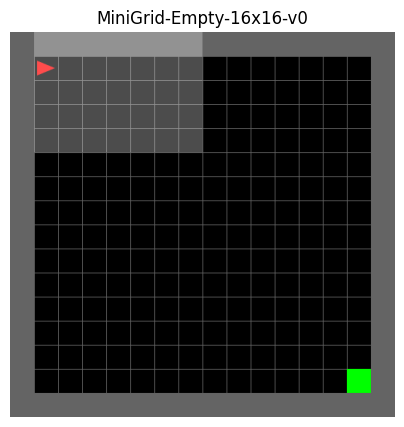

In [25]:
# TODO
# Créer une version avec render_mode="rgb_array"
env_render = gym.make("MiniGrid-Empty-16x16-v0", render_mode="rgb_array")
obs, info = env_render.reset(seed=0)
frame = env_render.render()
# Afficher une frame avec matplotlib
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 5))
plt.imshow(frame)
plt.axis("off")
plt.title("MiniGrid-Empty-16x16-v0")
plt.show()


**Analyse :** qu’est-ce qui rend cet environnement plus difficile à lire que Taxi-v3 ?
l'observation il est partiel, l'agent ne voie que la zone claire devant lui , tout le reste est noir ne le vois pas aussi il n'ya pas de reward.


## 8. Politique aléatoire sur MiniGrid

In [26]:
# TODO
# Implémenter une politique aléatoire et l'évaluer sur plusieurs épisodes
def random_minigrid_policy(obs, env):
    return env.action_space.sample()

def run_minigrid_episodes(policy_fn, env_id, n=20, seed=0):
    env = gym.make(env_id)
    results = []
    for ep in range(n):
        obs, info = env.reset(seed=seed + ep)
        terminated, truncated = False, False
        total_reward, steps = 0, 0
        while not (terminated or truncated):
            action = policy_fn(obs, env)
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            steps += 1
        results.append({"steps": steps, "total_reward": total_reward, "success": terminated})
    env.close()
    return results

results_mg_random = run_minigrid_episodes(random_minigrid_policy, "MiniGrid-Empty-16x16-v0", n=20)
rewards_mg = [r["total_reward"] for r in results_mg_random]
print(f"[MiniGrid Aléatoire] Reward moy : {np.mean(rewards_mg):.4f}, Succès : {np.mean([r['success'] for r in results_mg_random])*100:.1f}%")


[MiniGrid Aléatoire] Reward moy : 0.0549, Succès : 15.0%


## 9. Politique réflexe minimale sur MiniGrid

In [27]:
# TODO
# Implémenter une politique à règles locales simples
def reflex_minigrid_policy(obs, env):
    image = obs["image"]  # grille de vision partielle
    front_cell = image[3, 6, 0]  # type de l'objet devant
    if front_cell == 2:  # mur devant
        return 1  # tourner a droite
    else:
        return 2  # avancer

In [29]:
# TODO
# Évaluer cette politique et comparer à l'aléatoire
results_mg_reflex = run_minigrid_episodes(reflex_minigrid_policy, "MiniGrid-Empty-16x16-v0", n=20)
print(f"[MiniGrid Reflexe] Reward moy : {np.mean([r['total_reward'] for r in results_mg_reflex]):.4f}")
print(f"[MiniGrid Réflexe] Succes     : {np.mean([r['success'] for r in results_mg_reflex])*100:.1f}%")

[MiniGrid Reflexe] Reward moy : 0.0000
[MiniGrid Réflexe] Succes     : 0.0%


**Analyse :** pourquoi cette politique peut-elle tourner en rond ?
Cette politique peut tourner en rond car si l'agent fait face a un mur, il tourne a droite, puis avance, peut trouver un autre mur, tourne encore... et entre en boucle dans un coin. Sans memoire de position, il n'a aucun moyen de savoir s'il repasse au meme endroit.

## 10. Politique d’exploration avec mémoire minimale

In [30]:
# TODO
# Implémenter une classe ou une fonction de politique avec mémoire légère
class MemoryPolicy:
    def __init__(self):
        self.visited = set()
        self.direction = 0  # 0=droite, 1=bas, 2=gauche, 3=haut

    def reset(self):
        self.visited = set()
        self.direction = 0

    def __call__(self, obs, env):
        image = obs["image"]
        front_cell = image[3, 6, 0]

        # Obtenir position depuis env (si accessible)
        try:
            pos = tuple(env.unwrapped.agent_pos)
            self.visited.add(pos)
        except:
            pass

        if front_cell == 2:  # mur → tourner
            return 1  # tourner droite
        else:
            return 2  # avancer


In [31]:
# TODO
# Évaluer cette politique et comparer les résultats
def run_memory_episodes(env_id, n=20, seed=0):
    env = gym.make(env_id)
    policy = MemoryPolicy()
    results = []
    for ep in range(n):
        obs, info = env.reset(seed=seed + ep)
        policy.reset()
        terminated, truncated = False, False
        total_reward, steps = 0, 0
        while not (terminated or truncated):
            action = policy(obs, env)
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            steps += 1
        results.append({"steps": steps, "total_reward": total_reward, "success": terminated})
    env.close()
    return results

results_mg_memory = run_memory_episodes("MiniGrid-Empty-16x16-v0", n=20)
print(f"[MiniGrid Memoire] Succes : {np.mean([r['success'] for r in results_mg_memory])*100:.1f}%")


[MiniGrid Memoire] Succes : 0.0%


## 11. Wrapper utile : RecordEpisodeStatistics

In [32]:
# TODO
from gymnasium.wrappers import RecordEpisodeStatistics

# Appliquer le wrapper à l'un des environnements et observer info["episode"]
env = gym.make("Taxi-v3")
env = RecordEpisodeStatistics(env)

obs, info = env.reset(seed=0)
terminated, truncated = False, False

while not (terminated or truncated):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)

print("info['episode']:", info.get("episode"))

info['episode']: {'r': -749.0, 'l': 200, 't': 0.042561}


## 12. Comparaison finale

In [33]:
# TODO
# Construire un tableau récapitulatif de toutes les politiques testées
print(f"{'Env':<12} {'Politique':<20} {'Reward moy':>12} {'Steps moy':>10} {'Succes':>8}")
print("-" * 67)
# Taxi
for label, res in [("Aleatoire", results_random), ("Contrainte", results_constrained), ("Heuristique", results_heuristic)]:
    r = np.mean([x["total_reward"] for x in res])
    s = np.mean([x["steps"] for x in res])
    succ = np.mean([x["success"] for x in res]) * 100
    print(f"{'Taxi-v3':<12} {label:<20} {r:>12.2f} {s:>10.1f} {succ:>7.1f}%")
# MiniGrid
for label, res in [("Aleatoire", results_mg_random), ("Reflexe", results_mg_reflex), ("Memoire", results_mg_memory)]:
    r = np.mean([x["total_reward"] for x in res])
    s = np.mean([x["steps"] for x in res])
    succ = np.mean([x["success"] for x in res]) * 100
    print(f"{'MiniGrid':<12} {label:<20} {r:>12.4f} {s:>10.1f} {succ:>7.1f}%")


Env          Politique              Reward moy  Steps moy   Succes
-------------------------------------------------------------------
Taxi-v3      Aleatoire                 -758.70      197.4    10.0%
Taxi-v3      Contrainte                -521.10      192.3     5.0%
Taxi-v3      Heuristique               -147.05      152.3    25.0%
MiniGrid     Aleatoire                  0.0549      978.5    15.0%
MiniGrid     Reflexe                    0.0000     1024.0     0.0%
MiniGrid     Memoire                    0.0000     1024.0     0.0%


### Réponses de synthèse

1. Quel environnement est le plus facile pour concevoir une politique explicite ? Pourquoi ?
Taxi-v3, car il a une grille visible et les regles sont trivial a ecrire.

2. Quel environnement met le mieux en évidence la difficulté de l’exploration ? Pourquoi ?
MiniGrid, car l'agent ne voit qu'une portion de la grille, ne connait pas sa position globale,et toutes les politiques codees à la main echouent a 0% de succes malgré 1024 steps.

3. Quelles sont les limites principales des politiques codées à la main ?
Elles necessitent une connaissance experte de l'environnement, ne generalisent pas, atteignent rapidement un plafond de performance et n'apprennent pas de l'experience.
4. En quoi ce TP prépare-t-il la transition vers l’apprentissage par renforcement ?
Il montre que les politiques manuelles sont insuffisantes et installe les briques fondamentales du RL : boucle reset → step → reward, recompense cumulee à maximiser, et distinction terminated / truncated.

## Visualisation d'un épisode : image et vidéo

Dans cette partie, vous allez **visualiser** le comportement d'une politique :
- soit sous forme de **quelques images (frames)** ;
- soit sous forme de **vidéo** à l'aide du wrapper `RecordVideo`.

L'objectif est de **comparer visuellement** les différentes politiques, et pas seulement avec des métriques numériques.


### Partie 1 — Capturer quelques images d'un épisode

Compléter la fonction suivante pour :
1. créer un environnement avec `render_mode="rgb_array"` ;
2. exécuter un épisode avec une politique donnée ;
3. stocker quelques frames ;
4. retourner la liste des images capturées.


In [ ]:
import matplotlib.pyplot as plt

def capture_episode_frames(env_id, policy_fn, seed=0, max_steps=200):
    env = gym.make(env_id, render_mode="rgb_array")

    # TODO
    # 1. reset l'environnement
    # 2. exécuter l'épisode
    # 3. appeler env.render() pour récupérer les images
    # 4. stocker plusieurs frames dans une liste
    # 5. fermer l'environnement
    # 6. retourner la liste des frames

    frames = []

    obs, info = env.reset(seed=seed)
    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated) and steps < max_steps:
        frame = env.render()
        frames.append(frame)

        action = policy_fn(obs, info, env, steps)
        obs, reward, terminated, truncated, info = env.step(action)
        steps += 1

    env.close()
    return frames

### Afficher quelques frames

Compléter la cellule suivante pour afficher :
- la première frame ;
- une frame intermédiaire ;
- la dernière frame.


In [ ]:
def show_selected_frames(frames):
    # TODO
    # Afficher 3 images représentatives de l'épisode
    if len(frames) == 0:
        print("Aucune frame capturée.")
        return

    indices = [0, len(frames)//2, len(frames)-1]
    for idx in indices:
        plt.figure(figsize=(4, 4))
        plt.imshow(frames[idx])
        plt.axis("off")
        plt.title(f"Frame {idx}")
        plt.show()

### Exemple de politique aléatoire générique

Vous pouvez utiliser cette politique pour tester la capture d'images.


In [ ]:
def generic_random_policy(obs, info, env, step_idx):
    return env.action_space.sample()

In [ ]:
# Exemple à tester
frames_taxi_random = capture_episode_frames("Taxi-v3", generic_random_policy, seed=0, max_steps=100)
show_selected_frames(frames_taxi_random)

### Partie 2 — Enregistrer une vidéo avec `RecordVideo`

Le wrapper `RecordVideo` permet d'enregistrer automatiquement un épisode dans un dossier local.


In [ ]:
from gymnasium.wrappers import RecordVideo
from pathlib import Path

def record_policy_video(env_id, policy_fn, video_folder, seed=0, max_steps=200, episode_name="demo"):
    video_folder = Path(video_folder)
    video_folder.mkdir(parents=True, exist_ok=True)

    env = gym.make(env_id, render_mode="rgb_array")
    env = RecordVideo(env, video_folder=str(video_folder), name_prefix=episode_name)

    # TODO
    # 1. lancer un épisode
    # 2. exécuter la politique jusqu'à la fin
    # 3. fermer proprement l'environnement
    # 4. retourner le chemin du dossier contenant la vidéo

    obs, info = env.reset(seed=seed)
    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated) and steps < max_steps:
        action = policy_fn(obs, info, env, steps)
        obs, reward, terminated, truncated, info = env.step(action)
        steps += 1

    env.close()
    return video_folder

### Test — Enregistrer une vidéo de la politique aléatoire

Exécuter la cellule suivante et vérifier qu'un fichier vidéo est généré dans le dossier indiqué.


In [ ]:
video_path = record_policy_video(
    env_id="MiniGrid-Empty-16x16-v0",
    policy_fn=generic_random_policy,
    video_folder="videos_minigrid_random",
    seed=0,
    max_steps=150,
    episode_name="random_policy"
)
video_path

### Partie 3 — Comparer visuellement plusieurs politiques

Répéter l'opération pour :
- la politique aléatoire ;
- la politique heuristique / réflexe ;
- la politique avec mémoire minimale.

Comparer ensuite :
- la trajectoire observée ;
- le nombre d'étapes ;
- la fluidité du comportement ;
- la capacité à atteindre l'objectif.


In [ ]:
# TODO
# Produire ici 2 ou 3 vidéos pour comparer les politiques sur Taxi ou MiniGrid.

# Exemple attendu :
# record_policy_video(... politique aléatoire ...)
# record_policy_video(... politique heuristique ...)
# record_policy_video(... politique avec mémoire ...)

### Questions d'analyse visuelle

1. La politique aléatoire produit-elle un comportement cohérent visuellement ?
2. Quelle politique semble la plus efficace à l'observation ?
3. Voyez-vous des hésitations, répétitions ou blocages ?
4. Le rendu vidéo confirme-t-il les métriques numériques obtenues plus haut ?
5. Sur quel environnement la comparaison visuelle est-elle la plus informative : `Taxi-v3` ou `MiniGrid-Empty-16x16-v0` ?


### Extension facultative

Créer un tableau comparatif du type :

| Environnement | Politique | Reward moyenne | Succès | Observation visuelle |
|---|---:|---:|---:|---|
| Taxi-v3 | Aléatoire | ... | ... | ... |
| Taxi-v3 | Heuristique | ... | ... | ... |
| MiniGrid | Aléatoire | ... | ... | ... |
| MiniGrid | Mémoire minimale | ... | ... | ... |

Cela vous aidera à relier **analyse quantitative** et **analyse visuelle**.
